# Week 7: Визуализации по витрине `russia_gdp` (или `mart_stats`)

1. **Подготовка данных**
2. **Три вопроса к данным**
3. **Выводы по графикам**
4. **Сохранение графиков (PNG) и воспроизводимость**

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json


def load_state(state_path: str = "../data/state/state.json") -> dict:
    path = Path(state_path)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    else:
        raise FileNotFoundError(f"state.json not found: {path}")

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")


state = load_state()
TIMESTAMP = state["timestamp"]
path = f"../data/mart/variant_09/mart_yearly_{TIMESTAMP}.csv"

df = pd.read_csv(path)

display(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Types:\n", df.dtypes)
print("NaN:\n", df.isna().sum())

df["year"] = pd.to_datetime(df["year"], format="%Y")

,year,country_name,gdp,gdp_diff,gdp_growth_pct
0,2024,Россия,2173.84,NaN,NaN
1,2023,Россия,2071.51,-1.023301e+11,-4.707351
2,2022,Россия,2291.61,2.201064e+11,10.625430
3,2021,Россия,1829.19,-4.624254e+11,-20.179043
4,2020,Россия,1493.08,-3.361108e+11,-18.374878


Shape: (37, 5)
Columns: ['year', 'country_name', 'gdp', 'gdp_diff', 'gdp_growth_pct']
Types:
 year                int64
country_name          str
gdp               float64
gdp_diff          float64
gdp_growth_pct    float64
dtype: object
NaN:
 year              0
country_name      0
gdp               0
gdp_diff          1
gdp_growth_pct    1
dtype: int64


# Вопросы к данным

1. **Временной вопрос**
   Как менялся объём GDP России по годам? Есть ли периоды резкого роста / падения?

2. **Вопрос распределения**
   Каково распределение значений GDP по годам: нормальное или "толстохвостое"?

3. **Вопрос ранжирования**
   Какие годы были "лидерами" по GDP? Какие были худшими?

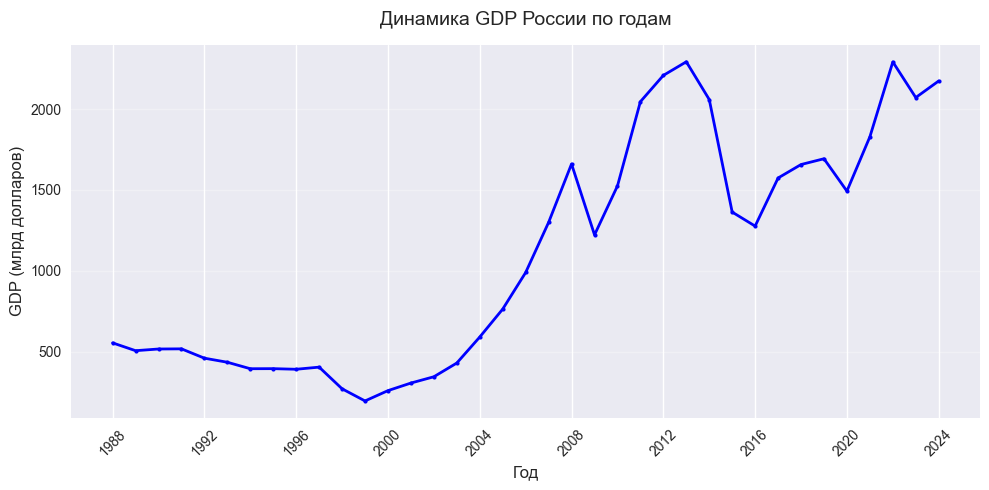

In [40]:
# Cell 2: Временной ряд GDP
plt.figure(figsize=(10, 5))
df_sorted = df.sort_values("year")

plt.plot(
    df_sorted["year"],
    df_sorted["gdp"],
    marker="o",
    linewidth=2,
    markersize=3,
    color="blue"
)

plt.title("Динамика GDP России по годам", fontsize=14, pad=15)
plt.xlabel("Год", fontsize=12)
plt.ylabel("ВВП (млрд долларов)", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(True, axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("../docs/figures/week7_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## Вывод по временному ряду

График показывает, что заметный рост ВВП наблюдался до 2013 года, после чего показатель временно снизился, но начал восстанавливаться в 2022 году.

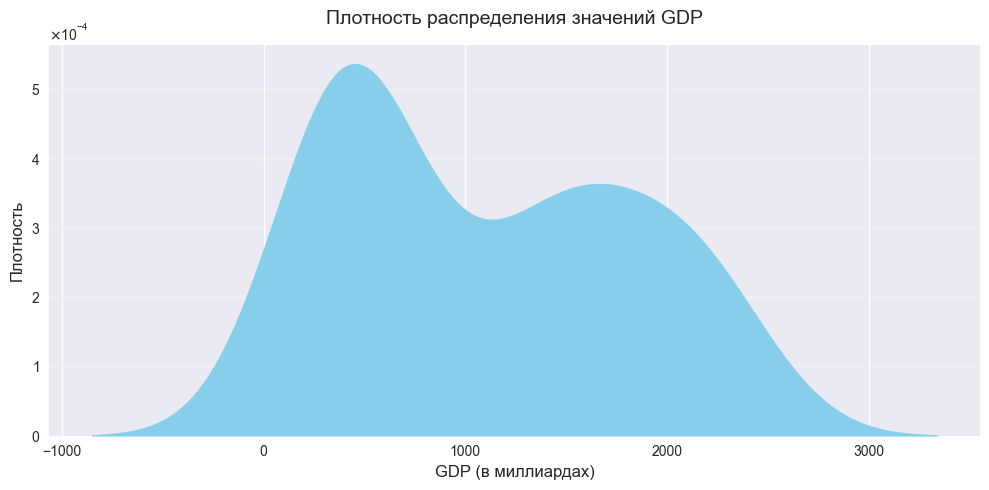

In [47]:
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(10, 5))

sns.kdeplot(data=df, x="gdp", fill=True, color="skyblue", alpha=1)

plt.title("Плотность распределения значений GDP", fontsize=14, pad=15)
plt.xlabel("ВВП (в миллиардах долларов)", fontsize=12)
plt.ylabel("Плотность", fontsize=12)

# Включаем научную запись для оси Y
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

plt.grid(True, axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("../docs/figures/week7_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Вывод по распределению

Распределение значений ВВП явно несимметричное: есть два "бугра" - около 500 и 1500 млрд. Значит, цифры около этих значений были самыми частыми в статистике.

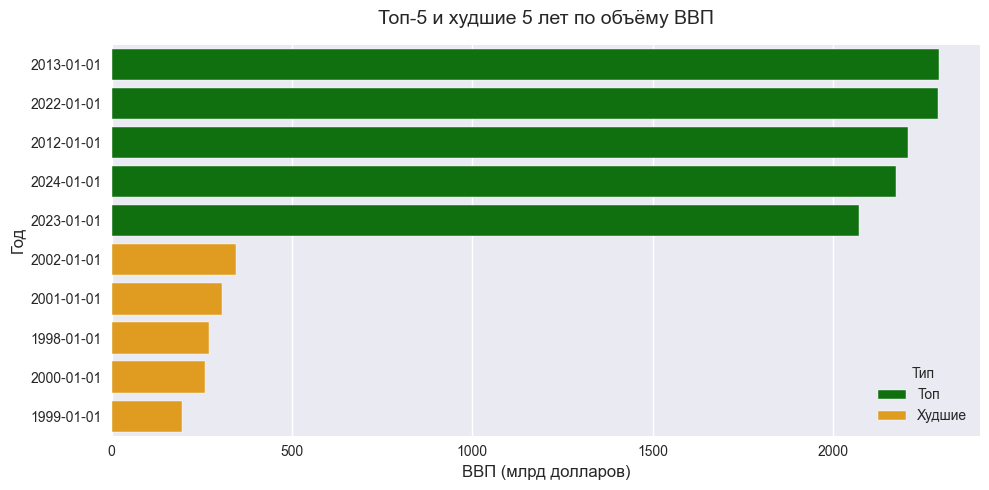

In [61]:
# График 3: ранжирование — топ‑5 и худшие 5 лет по GDP
top_gdp = df.nlargest(5, "gdp").copy()
top_gdp["type"] = "Топ"

bottom_gdp = df.nsmallest(5, "gdp").copy()
bottom_gdp["type"] = "Худшие"


combined = pd.concat([top_gdp, bottom_gdp], axis=0)
combined = combined.sort_values("gdp", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=combined,
    y="year",
    x="gdp",
    hue="type",
    dodge=False,
    palette=["green", "orange"],
)

plt.title("Топ-5 и худшие 5 лет по объёму ВВП", fontsize=14, pad=15)
plt.xlabel("ВВП (млрд долларов)", fontsize=12)
plt.ylabel("Год", fontsize=12)
plt.legend(title="Тип", loc="lower right")

plt.tight_layout()
plt.savefig("../docs/figures/week7_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## Вывод по ранжированию

Лидерами по ВВП с практически одинаковыми значенями являются 2013 и 2022 года, дальше идут соседи этих годов.
В худшей пятёрке находятся период конца 90-х и начала 2000-х, что может быть связано с кризисами.